# Clusterización de segmentation data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:

# Cargar los datos
data = pd.read_csv(r'C:\americo\ia_dema\12_Machine Learning\03_Clusterización\Ejercicio\segmentation data.csv')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


### Seleccionar variables relevantes para clustering (excluyendo ID)
### Podemos usar todas o seleccionar algunas como edad, ingresos, educación

In [42]:

#X = data[['Age', 'Income', 'Education','Sex', 'Occupation', 'Marital status']]  # Puedes ajustar estas variables
X = data[['Age', 'Income', 'Education']]

In [43]:
X.head()

,Age,Income,Education
0,67,124670,2
1,22,150773,1
2,49,89210,1
3,45,171565,1
4,53,149031,1


### Estandarizar los datos

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Método del codo para determinar número óptimo de clusters

In [45]:
wcss = []
silhouette_scores = []
range_values = range(2, 11)

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    if i > 1:  # Silhouette score no funciona con 1 cluster
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


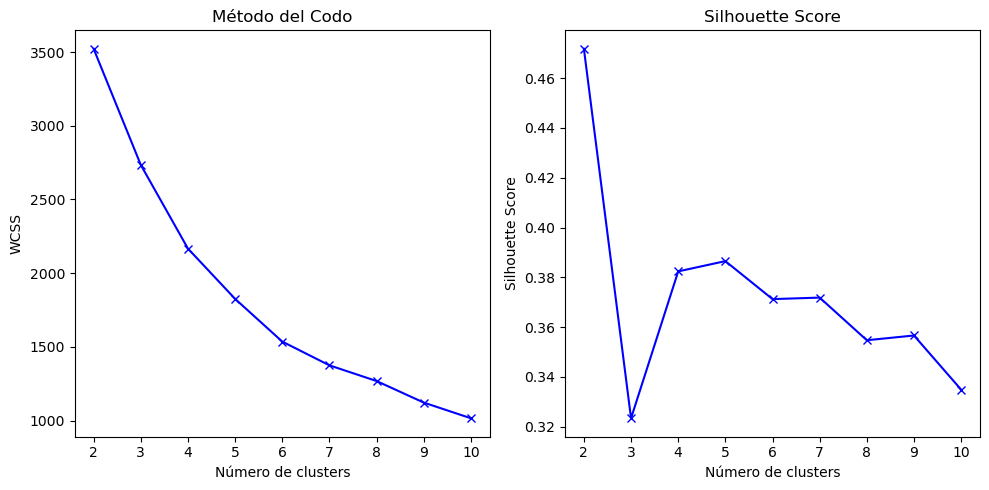

In [46]:

# Graficar el método del codo
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range_values, wcss, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.title('Método del Codo')

# Graficar silhouette scores
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

In [47]:
import warnings
warnings.filterwarnings('ignore')

In [49]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Age        2000 non-null   int64
 1   Income     2000 non-null   int64
 2   Education  2000 non-null   int64
dtypes: int64(3)
memory usage: 47.0 KB


In [50]:
X.columns

Index(['Age', 'Income', 'Education'], dtype='object')

Representación gráfica de las tres variables numéricas. La variable categórica "Gender" la representamos como color.

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


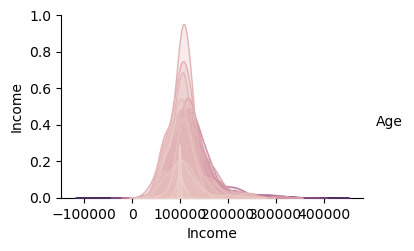

In [54]:

sns.pairplot(X.drop('Education', axis=1), hue='Age', aspect=1.5)
plt.show()

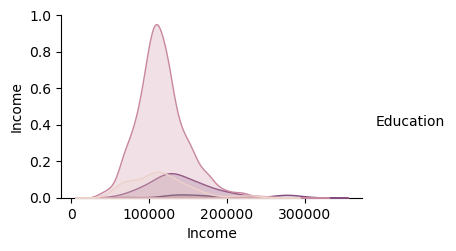

In [55]:
sns.pairplot(X.drop('Age', axis=1), hue='Education', aspect=1.5)
plt.show()

In [56]:
X_sin_normalizar = X.copy()
# Normalizamos X con MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [57]:
X.describe()

,Age,Income,Education
count,2000.000000,2000.000000,2000.000000
mean,0.308776,0.311197,0.346000
std,0.202059,0.139321,0.199927
min,0.000000,0.000000,0.000000
25%,0.155172,0.226048,0.333333
50%,0.258621,0.291434,0.333333
75%,0.413793,0.373778,0.333333
max,1.000000,1.000000,1.000000


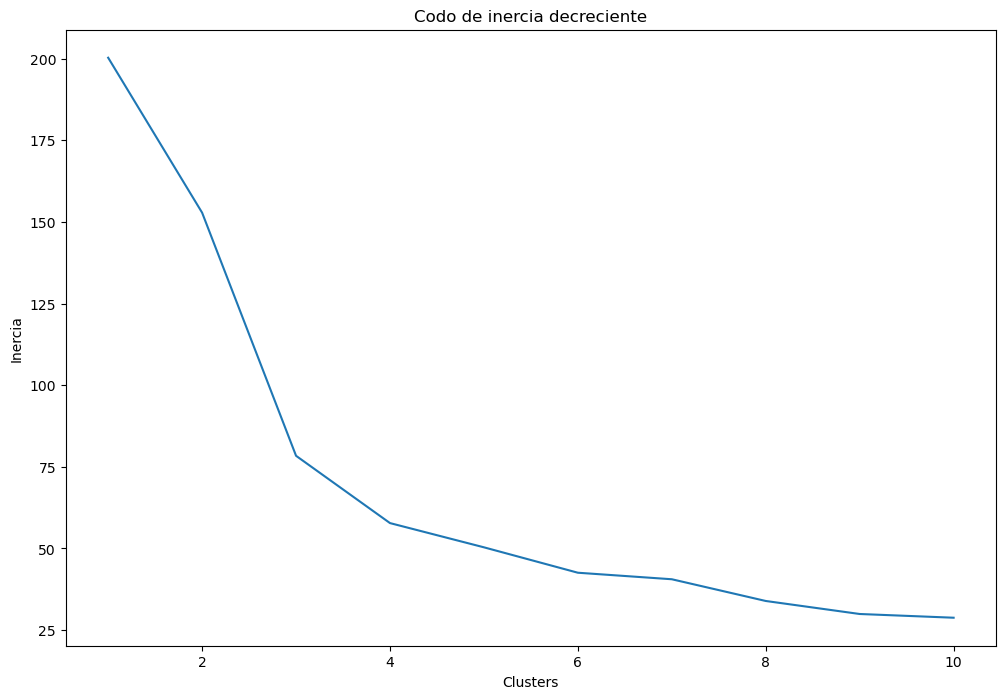

In [58]:
from sklearn.cluster import KMeans

clusters = []

for i in range(1, 11):
    km = KMeans(n_clusters=i).fit(X)
    clusters.append(km.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Codo de inercia decreciente')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inercia')

# Annotate arrow
ax.annotate('Posible codo válido', xy=(3, 140000), xytext=(3, 50000), xycoords='data',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))

ax.annotate('Posible codo válido', xy=(5, 80000), xytext=(5, 150000), xycoords='data',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))

plt.show()

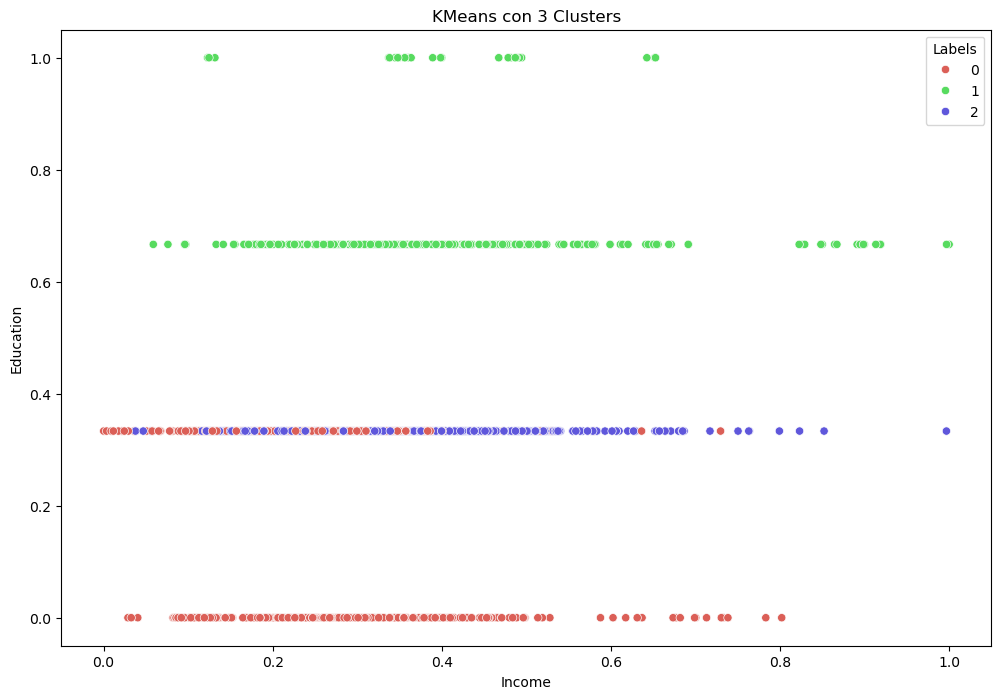

In [62]:
# Prueba con 3 clusters
clusters = 3
km3 = KMeans(n_clusters = clusters).fit(X)

# Las etiquetas atribuidas se colocan en la columna "Labels"
X_kmeans_3 = X.copy()
labels_3 = km3.labels_
X_kmeans_3['Labels'] = labels_3

# Gráfico
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_kmeans_3['Income'], y=X_kmeans_3['Education'], hue=X_kmeans_3['Labels'], palette=sns.color_palette('hls', clusters))
plt.title(f'KMeans con {clusters} Clusters')
plt.show()